# Baseline Model Evaluation
This notebook evaluates the pre-trained `SamLowe/roberta-base-go_emotions` model to establish a strong baseline for our project. We can later use these results to compare against our own custom-trained models.

In [1]:
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Add the source folder to sys.path so we can import our modules
source_code_path = os.path.abspath('../source')
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from visualizations import *
from modeling import *

### 1. Load the Dataset

As seen in the exploration notebook, since the goal is to predict the emotions of a text based ONLY on the text itself, from now on we will only use the aggeregated dataset, which contains the text and the 28 emotion labels. The original dataset contains also other columns (e.g., source, author, etc.) that we will not use for our task. This new version of the dataset, has also in account that the problem is multilabeled, meaning that some texts have multiple emotions associated with it.

In [2]:
# Load the dataset using the utility function
dataset_original = load_dataset('../data/GoEmotions_multilabel.csv')

# Display the first few rows to verify it loaded correctly
dataset_original.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [3]:
dataset = dataset_original.copy()

## <font color='#BFD72F' size=6>2 Modeling</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)

After exploring the dataset, and having our pipeline for preprocessing created, we can move on to actually testing different models and understand how well they can predict the emotions of the texts.

To understand how diferent preprocessing techniques affect the performance of the model, we will apply three different preprocessings, and use these 3 versions of the text throughout the rest of the project.

### <font color='#BFD72F' size=6>2.1 Creating preprocessed versions</font> <a class="anchor" id="2.1"></a>
  
[Back to TOC](toc)

In [4]:
# Text with translated emojis, hastags, urls (basically the minimal preprocessing to be done, that the allows the model to fully understand every component of the text, without taking the 'emotion' out of it. ) 
dataset['01_minimal_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=False,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [5]:
# Medium Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['02_medium_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [6]:
# Harsh Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['03_harsh_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [7]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].iloc[818].values)

print("\nMinimal Preprocessing Sample:\n")
print(dataset[['01_minimal_preprocessing']].iloc[818].values)

print("\nMedium Preprocessing Sample:\n")
print(dataset[['02_medium_preprocessing']].iloc[818].values)

print("\nHarsh Preprocessing Sample:\n")
print(dataset[['03_harsh_preprocessing']].iloc[818].values)

Original Text Sample:

["/uj I would've thought this was pics had it not been for your commie t"]

Minimal Preprocessing Sample:

['/uj I would have thought this was pics had it not been for your commie t']

Medium Preprocessing Sample:

['uj i wouldve thought this was pics had it not been for your commie t']

Harsh Preprocessing Sample:

['uj wouldve thought pics commie']


Just as some final exploration we will see the most common words in the 3 different preprocessings.

In [8]:
# Analyze Minimal preprocessing
vectorizer = CountVectorizer(max_df=0.8, min_df=5)
X_minimal = vectorizer.fit_transform(dataset['01_minimal_preprocessing'])
words_minimal = vectorizer.get_feature_names_out()
total_counts_minimal = X_minimal.sum(axis=0).A1
df_words_minimal = pd.DataFrame({'word': words_minimal, 'count': total_counts_minimal}).sort_values(by='count', ascending=False)
print("Top 10 words (Minimal preprocessing):")
print(df_words_minimal.head(10))

# Analyze Medium preprocessing
X_medium = vectorizer.fit_transform(dataset['02_medium_preprocessing'])
words_medium = vectorizer.get_feature_names_out()
total_counts_medium = X_medium.sum(axis=0).A1
df_words_medium = pd.DataFrame({'word': words_medium, 'count': total_counts_medium}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Medium preprocessing):")
print(df_words_medium.head(10))

# Analyze Harsh preprocessing
X_harsh = vectorizer.fit_transform(dataset['03_harsh_preprocessing'])
words_harsh = vectorizer.get_feature_names_out()
total_counts_harsh = X_harsh.sum(axis=0).A1
df_words_harsh = pd.DataFrame({'word': words_harsh, 'count': total_counts_harsh}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Harsh preprocessing):")
print(df_words_harsh.head(10))

Top 10 words (Minimal preprocessing):
      word  count
6880   the  24085
3674    is  18188
6984    to  17015
7725   you  15321
3687    it  14492
6878  that  12998
364    and  12091
4617   not  10791
4491  name  10454
4683    of   9569

Top 10 words (Medium preprocessing):
      word  count
6884   the  24078
6990    to  17012
7733   you  13195
376    and  12080
3680    is  11323
6880  that  10658
3692    it  10510
4495  name  10447
4686    of   9568
6918  this   8731

Top 10 words (Harsh preprocessing):
        word  count
4433    name  10447
3937    like   4411
2092    dont   3244
7555   would   2744
6795   thats   2484
2933     get   2483
4663     one   2440
4032    love   2411
4891  people   2310
2993    good   2272


Word cloud saved to wordclouds/01_minimal_preprocessing.png


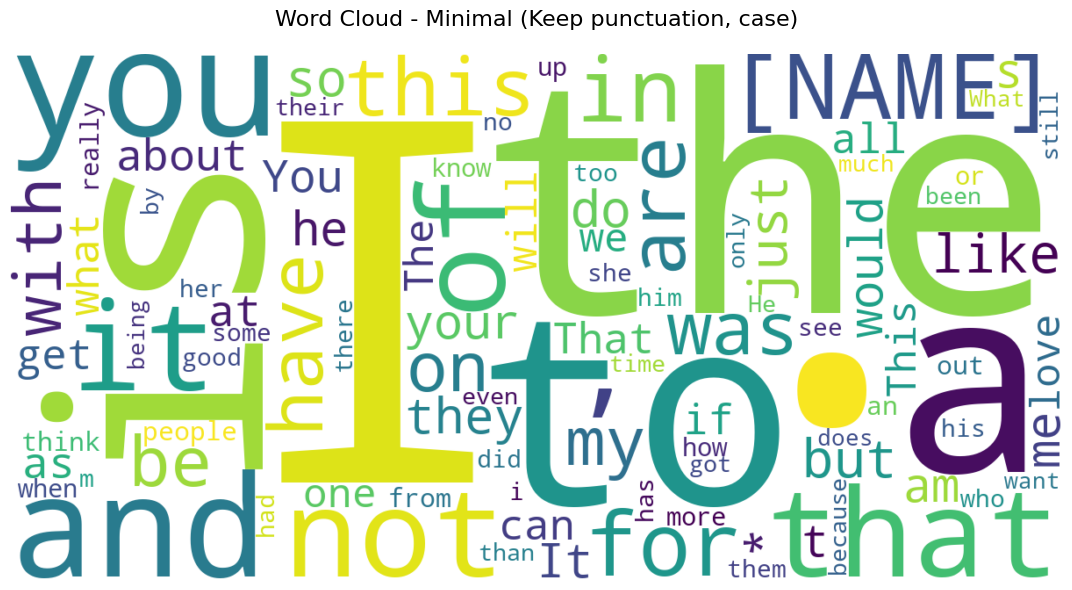

Word cloud saved to wordclouds/02_medium_preprocessing.png


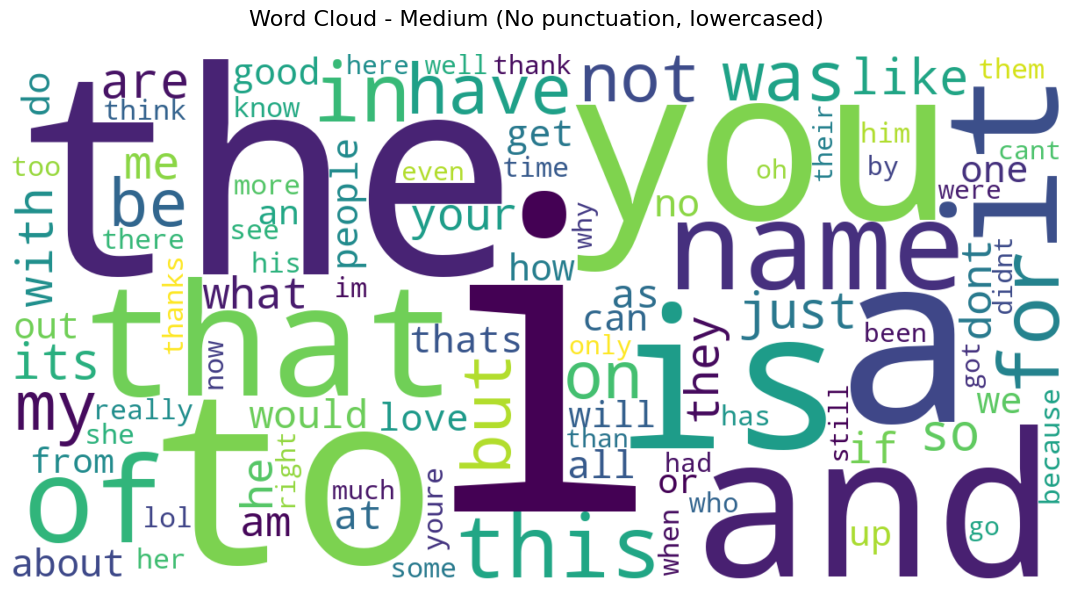

Word cloud saved to wordclouds/03_harsh_preprocessing.png


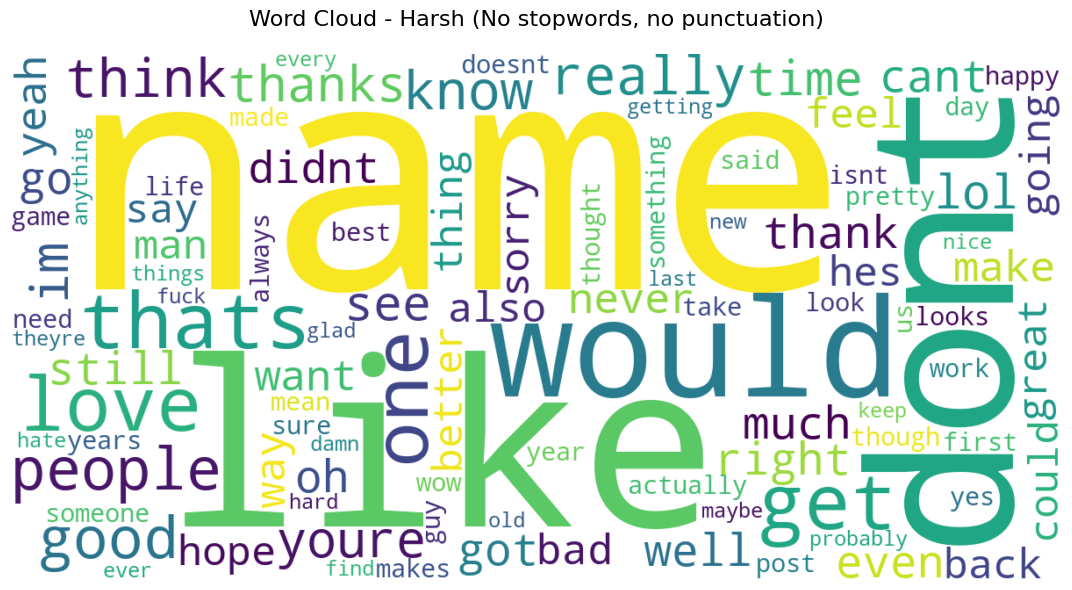

In [9]:
# Define your preprocessing versions
preprocessing_cols = {
    '01_minimal_preprocessing': 'Minimal (Keep punctuation, case)',
    '02_medium_preprocessing': 'Medium (No punctuation, lowercased)',
    '03_harsh_preprocessing': 'Harsh (No stopwords, no punctuation)'
}

# Generate word clouds for all versions
for col, description in preprocessing_cols.items():
    wordcloud_from_text(
        dataset[col],
        title=f"Word Cloud - {description}",
        max_words=100,
        colormap='viridis',
        save_path=f'wordclouds/{col}.png'
    )

It is expected that the more preprocessing we do the worse the model will perform sibnce this tasks constitutes in classifing the emotions of the text, wgich is normally deapily correlated with punctuation, stopwords, and repeated characters. 

In [10]:
dataset

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,pride,realization,relief,remorse,sadness,surprise,neutral,01_minimal_preprocessing,02_medium_preprocessing,03_harsh_preprocessing
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,1,"""If you do not wear BROWN AND ORANGE...YOU DON...",if you dont wear brown and orangeyou dont matt...,dont wear brown orangeyou dont matter need tsh...
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,"""What do Scottish people look like?"" How I wou...",what do scottish people look like how i would ...,scottish people look like would love take swin...
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,"A surprise, to be sure, but a welcome one",a surprise to be sure but a welcome one,surprise sure welcome one
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,"' * Pray *, v. To ask that the laws of the uni...",pray v to ask that the laws of the universe be...,pray v ask laws universe annulled behalf singl...
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,"> it will get invaded by tankie, unfortunately...",itll get invaded by tankie unfortunately how a...,itll get invaded tankie unfortunately apropos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57727,🤷🏻‍♀️ As a wise man once said: he was a bastar...,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,emoji_woman_shrugging_light_skin_tone As a wis...,emoji_woman_shrugging_light_skin_tone as a wis...,emoji_woman_shrugging_light_skin_tone wise man...
57728,🤷🏼‍♀️ I was wondering the same thing. It looke...,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,emoji_woman_shrugging_medium-light_skin_tone I...,emoji_woman_shrugging_medium light_skin_tone i...,emoji_woman_shrugging_medium light_skin_tone w...
57729,🦀MY BABYS DEAD🦀,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,emoji_crabMY BABYS DEADemoji_crab,emoji_crabmy babys deademoji_crab,emoji_crabmy babys deademoji_crab
57730,🦀🦀🦀🦀🦀🦀🦀🦀🦀I’m bad at this game🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀🦀,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,emoji_crabemoji_crabemoji_crabemoji_crabemoji_...,emoji_crabemoji_crabemoji_crabemoji_crabemoji_...,emoji_crabemoji_crabemoji_crabemoji_crabemoji_...


### 2. Apply the Baseline Model
Since evaluating all 200,000+ rows takes a significant amount of time, we first test it on a small sample of 100 rows.

In [11]:
test_data = dataset.head(100).copy()

# Apply to each preprocessing version with different output columns
df_minimal = apply_baseline_to_dataframe(
    df=test_data, 
    text_column='01_minimal_preprocessing',
    threshold=0.5,
    output_column='01_baseline_predictions'
)

df_medium = apply_baseline_to_dataframe(
    df=test_data, 
    text_column='02_medium_preprocessing',  
    threshold=0.5,
    output_column='02_baseline_predictions'
)

df_harsh = apply_baseline_to_dataframe(
    df=test_data, 
    text_column='03_harsh_preprocessing',  
    threshold=0.5,
    output_column='03_baseline_predictions'
)

# Combine all predictions into one DataFrame
test_data['01_baseline_predictions'] = df_minimal['01_baseline_predictions']
test_data['02_baseline_predictions'] = df_medium['02_baseline_predictions']
test_data['03_baseline_predictions'] = df_harsh['03_baseline_predictions']

# Display results
test_data[['text', 
           '01_minimal_preprocessing', '01_baseline_predictions',
           '02_medium_preprocessing', '02_baseline_predictions',
           '03_harsh_preprocessing', '03_baseline_predictions']].head(10)

Downloading/Loading model 'SamLowe/roberta-base-go_emotions' into memory...


Device set to use mps:0


Gathering predictions for 100 rows... This might take a moment!


Generating predictions: 100%|██████████| 100/100 [00:10<00:00,  9.56it/s]


Predictions completed successfully! Saved to column: '01_baseline_predictions'
Downloading/Loading model 'SamLowe/roberta-base-go_emotions' into memory...


...

Device set to use mps:0


Gathering predictions for 100 rows... This might take a moment!


Generating predictions: 100%|██████████| 100/100 [00:01<00:00, 50.09it/s]

Predictions completed successfully! Saved to column: '03_baseline_predictions'


,text,01_minimal_preprocessing,01_baseline_predictions,02_medium_preprocessing,02_baseline_predictions,03_harsh_preprocessing,03_baseline_predictions
0,"""If you don't wear BROWN AND ORANGE...YOU DON...","""If you do not wear BROWN AND ORANGE...YOU DON...",neutral,if you dont wear brown and orangeyou dont matt...,neutral,dont wear brown orangeyou dont matter need tsh...,neutral
1,"""What do Scottish people look like?"" How I wo...","""What do Scottish people look like?"" How I wou...",love,what do scottish people look like how i would ...,love,scottish people look like would love take swin...,love
2,"### A surprise, to be sure, but a welcome one","A surprise, to be sure, but a welcome one",surprise,a surprise to be sure but a welcome one,surprise,surprise sure welcome one,surprise
3,"'*Pray*, v. To ask that the laws of the unive...","' * Pray *, v. To ask that the laws of the uni...",neutral,pray v to ask that the laws of the universe be...,neutral,pray v ask laws universe annulled behalf singl...,neutral
4,">it'll get invaded by tankie, unfortunately. ...","> it will get invaded by tankie, unfortunately...",neutral,itll get invaded by tankie unfortunately how a...,neutral,itll get invaded tankie unfortunately apropos,neutral
5,>sexuality shouldn’t be a grouping category I...,> sexuality shouldn ’ t be a grouping category...,neutral,sexuality shouldnt be a grouping category it m...,neutral,sexuality shouldnt grouping category makes dif...,neutral
6,And not all children's hospitals need the sam...,And not all children is hospitals need the sam...,approval,and not all childrens hospitals need the same ...,approval,childrens hospitals need stuff call ask need l...,approval
7,"Best number! [NAME], [NAME], [NAME]","Best number! [NAME], [NAME], [NAME]",admiration,best number name name name,admiration,best number name name name,admiration
8,Calm down and relax are the worst things to s...,Calm down and relax are the worst things to sa...,annoyance,calm down and relax are the worst things to sa...,annoyance,calm relax worst things say woman ever,annoyance
9,"Change is hard. Find comfort in victory, even...","Change is hard . Find comfort in victory, even...",caring,change is hard find comfort in victory even th...,neutral,change hard find comfort victory even small on...,neutral


In [15]:
emotion_cols = [col for col in dataset.columns 
                if col not in ['text', '01_minimal_preprocessing', '02_medium_preprocessing', 
                              '03_harsh_preprocessing'] 
                and not col.endswith('_predictions')]

In [16]:
prediction_cols = {
    'Minimal Preprocessing': '01_baseline_predictions',
    'Medium Preprocessing': '02_baseline_predictions',
    'Harsh Preprocessing': '03_baseline_predictions'
}

In [17]:
comparison_df = create_model_comparison_df(
    df=test_data,  # or dataset_with_predictions
    emotion_cols=emotion_cols,
    prediction_cols=prediction_cols
)

In [18]:
comparison_df.head()

,model,micro_f1,macro_f1,samples_f1,weighted_f1,exact_match_ratio,hamming_loss,micro_precision,micro_recall,macro_precision,macro_recall,total_samples,error_count
0,Minimal Preprocessing,0.535135,0.305677,0.614071,0.473208,0.23,0.061429,0.942857,0.373585,0.640993,0.223071,100,0
1,Medium Preprocessing,0.519126,0.299685,0.599405,0.458075,0.23,0.062857,0.940594,0.358491,0.581232,0.220983,100,0
2,Harsh Preprocessing,0.498630,0.293817,0.592881,0.422091,0.24,0.065357,0.910000,0.343396,0.584900,0.217969,100,0


In [20]:
best_model = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'model']
best_f1 = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'macro_f1']
print(f"\n Best model based on Macro F1: {best_model} ({best_f1:.4f})")


 Best model based on Macro F1: Minimal Preprocessing (0.3057)
